# Module 3 Homework - Seaborn
Using a dataset about Pokemon combat statistic, we will practice data visualization using the seaborn library.  
<img src="https://cdn.arstechnica.net/wp-content/uploads/2020/07/pokemon-go-masks-800x450.jpg">

In this notebook, we will plot the relationships between different observations of the combat statistics of Pokémon. You will need to import a few packages, including `pandas`, `matplotlib.pyplot`, and `seaborn`. The data is stored in a csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv

Here are the descriptions of this dataset:
- `#` - Pokedex entry number of the Pokemon
- `Name` - name of the Pokemon
- `Type 1` - each Pokemon has a type, this determines weakness/resistance to attacks [referred to as the primary type]
- `Type 2` - some Pokemon are dual type and have 2 [referred to as the secondary type]
- `Total` - sum of all stats that come after this, a general guide to how strong a Pokemon is
- `HP` - hit points, or health, defines how much damage a Pokemon can withstand before fainting
- `Attack` - the base modifier for normal attacks
- `Defense` - the base damage resistance against normal attacks
- `Sp. Atk` - special attack, the base modifier for special attacks
- `Sp. Def` - the base damage resistance against special attacks
- `Speed` - determines which Pokemon attacks first each round
- `Generation` - refers to which grouping/game series the Pokemon was released in
- `Legendary` - a boolean that identifies whether the Pokemon is legendary

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

fp = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv"
df = pd.read_csv(fp)
df.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


## Q1: Plot the relationship between Attack and Defense
Create a relationship plot using seaborn's `relplot` function. Plot `Attack` on the x-axis and `Defense` on the y-axis. Use `hue` to display the `HP` (hit point) for each datapoint. You can choose your favorite palette. Include a meaninful title in the plot. After creating the plot, insert a markdown cell :immediately following the plot to describe the relationship between Attack and Defense in this dataset.

### From the plot, I observed....
Results: There is a positive correlation between `Attack` and `Defense`. The hit-points (`HP`) is higher for Pokemons with higher `Attack` and `Defense` values.

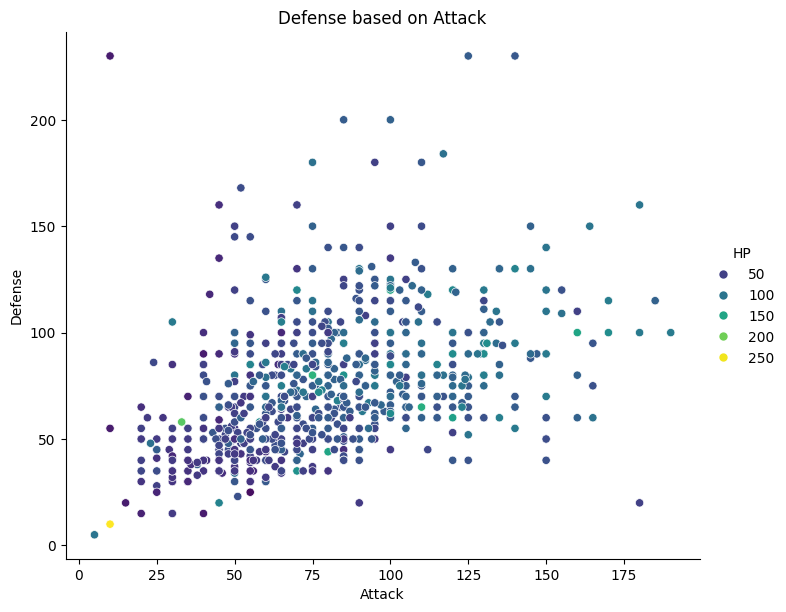

In [4]:
# Your code here . . .
sns.relplot(
    data=df,
    x="Attack",
    y="Defense",
    hue="HP",
    palette="viridis",
    height=6,
    aspect=1.2
)
plt.title("Defense based on Attack");
plt.show()

## Q2: Plot the relationship between Attack and Total using a hexbin plot
Create a hexbin plot using seaborn's `joinplot` function. Plot `Attack` on the x-axis and `Total` on the y-axis. You can choose the gridsize. Include a title for the plot "Attack vs total for all Pokemon". After generating the plot, insert a markdown cell to answer this question: The hexbin plot displays the relationship between `Attack` and `Total`, what else does this plot show?

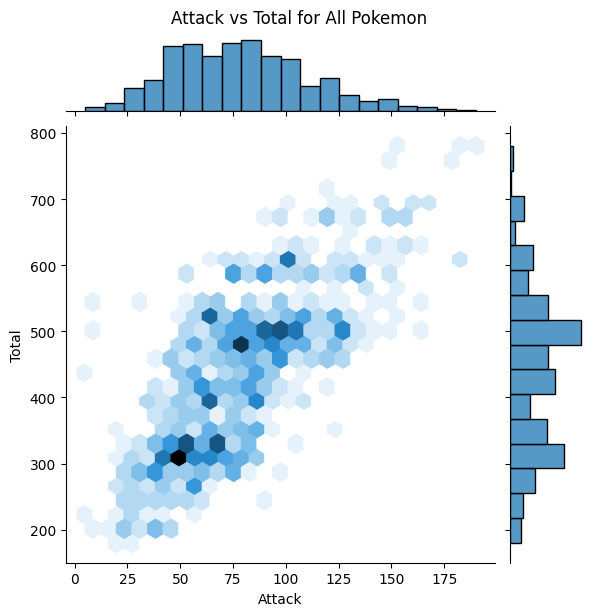

In [5]:
# Your code here . . .
sns.jointplot(
    data=df,
    x="Attack",
    y="Total",
    kind="hex",
    gridsize=25
)
plt.suptitle("Attack vs Total for All Pokemon", y=1.02)
plt.show()

From the plot, I observed there is a positive correlation between the attack amounts compared to the totals. I also noticed how there is a higher density for all Pokemon in the middle where the color of the hexagons are darker. This plot shows the most common areas for attacks and totals for all pokemon and where their relationship is most similar.

## Q3: Create two categorical plots for Pokemon types. `Type 1` and `Type 2` .
For each plot, the unique values of `Type 1` or `Type 2` should be plotted along the y-axis, and the counts of Pokemon should be on the x-axis. Use the color red for the `Type 1` plot and blue for the `Type 2` plot. After the two plots are displayed, insert a markdown cell to write your findings: Which are the most common `Type 1` and `Type 2` Pokemons, and which are the most rare ones?

It appears the most common Type 1 and Type 2 Pokemons are Water and Flying respectively. The most rare ones are Flying and Bug for Type 1 and Type 2 respectively.

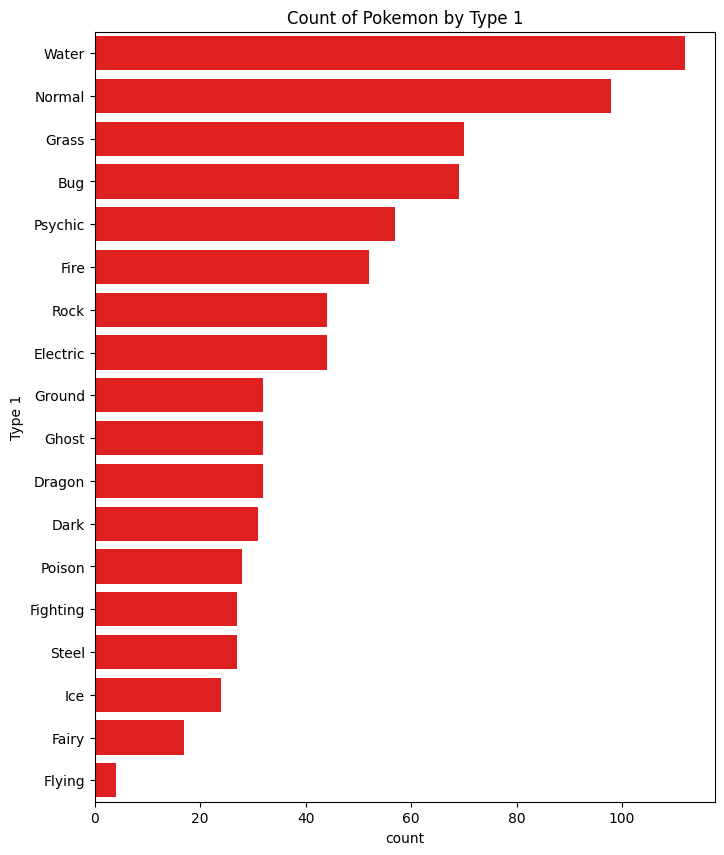

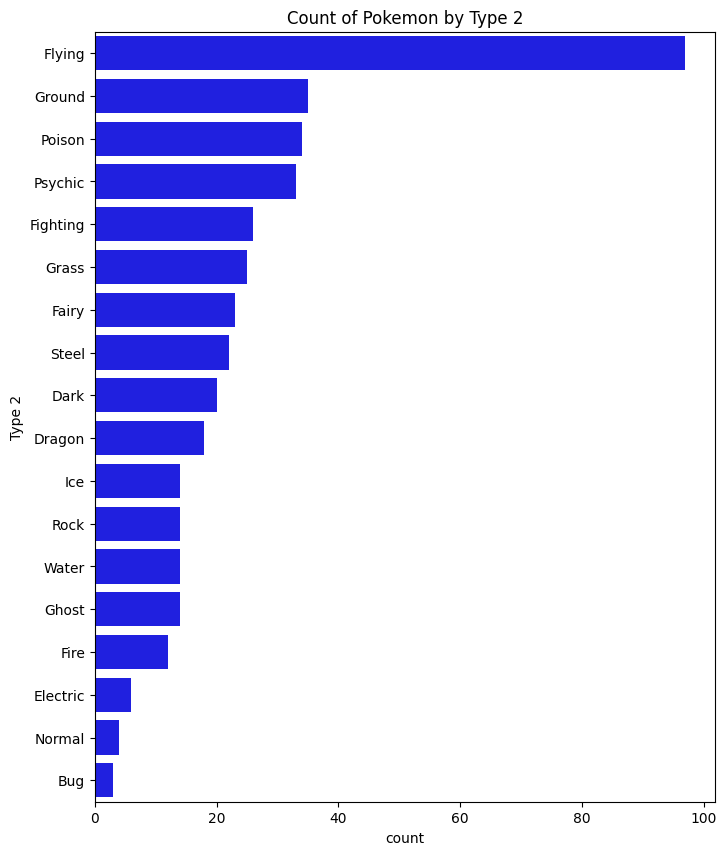

In [7]:
# Your code here . . .
plt.figure(figsize=(8,10))
sns.countplot(
    data=df,
    y="Type 1",
    color="red",
    order=df["Type 1"].value_counts().index
)
plt.title("Count of Pokemon by Type 1")
plt.show()

plt.figure(figsize=(8,10))
sns.countplot(
    data=df,
    y="Type 2",
    color="blue",
    order=df["Type 2"].value_counts().index
)
plt.title("Count of Pokemon by Type 2")
plt.show()

## Q4-6: Your own question
Come up with three more questions to further explore the pokemon dataset.

Your question(s) . . .

Do Legendary Pokémon have higher Total stats?

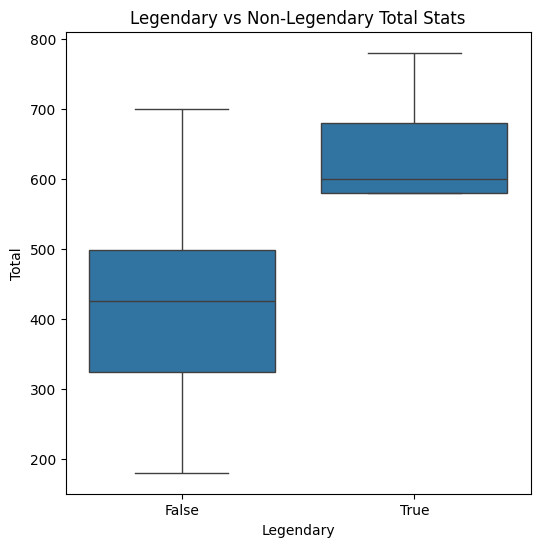

In [8]:
# Your code here . . .
plt.figure(figsize=(6,6))
sns.boxplot(
    data=df,
    x="Legendary",
    y="Total"
)

plt.title("Legendary vs Non-Legendary Total Stats")
plt.show()

How does Speed effect HP on a Pokemon?

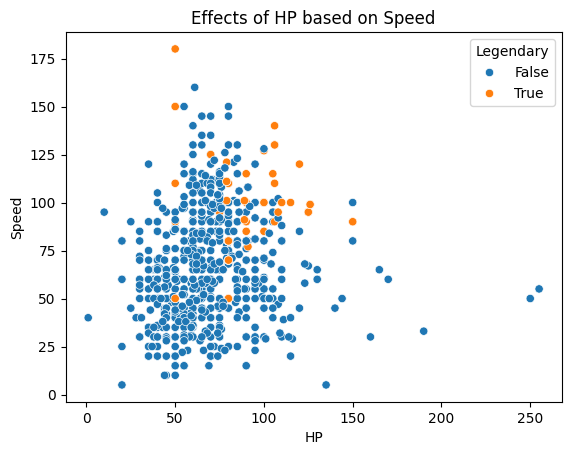

In [9]:
sns.scatterplot(
    data=df,
    x="HP",
    y="Speed",
    hue="Legendary"
)

plt.title("Effects of HP based on Speed")
plt.show()

What is the spread of new Pokemon per Generation?

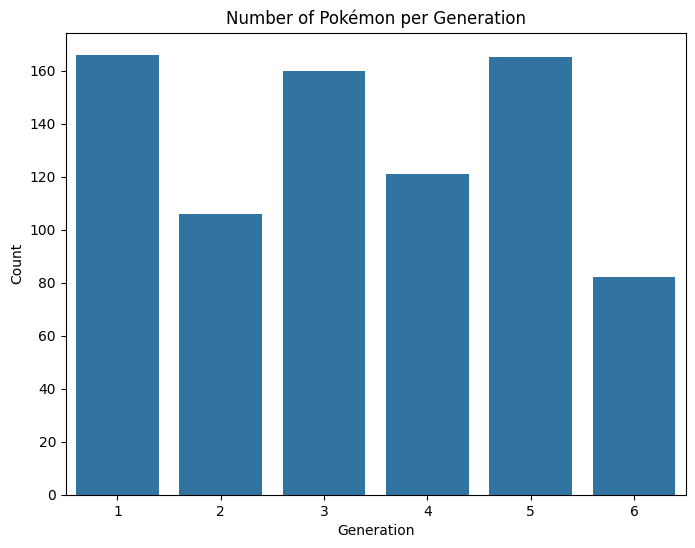

In [10]:
plt.figure(figsize=(8,6))

sns.countplot(
    data=df,
    x="Generation",
    order=sorted(df["Generation"].unique())
)

plt.title("Number of Pokémon per Generation")
plt.xlabel("Generation")
plt.ylabel("Count")
plt.show()